In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from numpy import genfromtxt
import os
import pandas as pd
import pickle
import seaborn as sns
import torch

from daart.data import DataGenerator
from daart.eval import get_precision_recall, run_lengths
from daart.io import get_expt_dir, find_experiment
from daart.models import Segmenter
from daart.transforms import ZScore

### define data paths

In [8]:
sns.set_context('talk')
sns.set_style('white')

from daart_scratch.session_ids_fly import \
    EXPT_IDS_TRAIN_5, EXPT_IDS_TRAIN_10, EXPT_IDS_TRAIN_15, EXPT_IDS_TRAIN_20, EXPT_IDS_ALL
expt_ids = EXPT_IDS_TRAIN_5[0]

base_dir = '/media/mattw/fly/behavior'
# save_path = os.path.join(base_dir, 'analysis', 'syllable-plots_model')
save_path = None # '/home/mattw/Dropbox/research-text/papers/2021-daart/figs/supp_performance_outputs_wabdomen'

# get experiment dir
expt_dir = get_expt_dir(os.path.join(base_dir, 'classifiers_no-abdomen'), expt_ids)
print(expt_dir)

marker_names = [
    'ab-top', 'ab-bot', 'hind-top', 'hind-bot', 'mid-top', 'mid-bot', 
    'fore-top', 'fore-bot']
n_markers = len(marker_names)

label_names = ['undefined', 'still', 'walk', 'front-groom', 'back-groom'] #, 'abdomen-move']
n_classes = len(label_names)

/media/mattw/fly/behavior/classifiers_no-abdomen/multi-1


### load model

In [9]:
model_type = 'gru'
tt_expt_dir = 'batch=2000_lr=1e-4' #_v4.2_split'

device = 'cuda'
batch_size = 2000
trial_splits = '9;1;0;0'

hparams = {
    'rng_seed_train': 0,
    'rng_seed_model': 0,
    'trial_splits': trial_splits,
    'train_frac': 1,
    'model_type': model_type,
    'batch_size': batch_size,
    'learning_rate': 1e-4,
    'n_hid_layers': 2,
    'n_hid_units': 32,
    'n_lags': 4 if model_type == 'dtcn' else 8,
    'activation': 'lrelu' if model_type == 'dtcn' else 'tanh',
    'l2_reg': 0,
    'device': device,
    'tt_expt_dir': os.path.join(expt_dir, model_type, tt_expt_dir),
    'bidirectional': True,
    'dropout': 0.1,
}

hparams['lambda_strong'] = 1
hparams['lambda_weak'] = 0.5
hparams['lambda_pred'] = 1 # 0.5
        
# load model
version_int = find_experiment(hparams)
version_str = str('version_%i' % version_int)
version_dir = os.path.join(hparams['tt_expt_dir'], version_str)
model_file = os.path.join(version_dir, 'best_val_model.pt')
arch_file = os.path.join(version_dir, 'hparams.pkl')
print('Loading model defined in %s' % arch_file)
with open(arch_file, 'rb') as f:
    hparams_new = pickle.load(f)
hparams_new['device'] = hparams.get('device', 'cpu')
model = Segmenter(hparams_new)
model.load_state_dict(torch.load(
    model_file, map_location=lambda storage, loc: storage))
model.to(hparams_new['device'])
model.eval()

Loading model defined in /media/mattw/fly/behavior/classifiers_no-abdomen/multi-1/gru/batch=2000_lr=1e-4/version_18/hparams.pkl


Segmenter(
  (model): RNN(
    (encoder): ModuleList(
      (GRU_layer_00): GRU(16, 32, num_layers=2, batch_first=True, bidirectional=True)
    )
    (classifier): ModuleList(
      (dense(classification)_layer_01): Linear(in_features=64, out_features=5, bias=True)
    )
    (predictor): ModuleList(
      (GRU(prediction)_layer_02): GRU(64, 32, num_layers=2, batch_first=True, bidirectional=True)
      (dense(prediction)_layer_03): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (class_loss): CrossEntropyLoss()
  (pred_loss): MSELoss()
)

### helper functions

In [14]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
# cmap0 = plt.get_cmap('tab20', 10)
# cmap = ListedColormap(['w', cmap0(0), cmap0(1), cmap0(2), cmap0(3), cmap0(4)])

cmap0 = [
    (233 / 255, 94 / 255, 13 / 255, 1),
    (55 / 255, 160 / 255, 85 / 255, 1),
    (226 / 255, 46 / 255, 39 / 255, 1),
    (121 / 255, 110 / 255, 178 / 255, 1),
    (18 / 255, 117 / 255, 207 / 255, 1),
]
# cmap = ListedColormap(['w', cmap0[0], cmap0[1], cmap0[2], cmap0[3], cmap0[4]])
cmap = ListedColormap(['w', cmap0[0], cmap0[1], cmap0[2], cmap0[3]])

def plot_markers_and_states(
        times, markers, states, title, ax, ymin=None, ymax=None, spc=None):
    if ymin is None:
        ymin = np.min(markers)
    if ymax is None:
        ymax = np.max(markers)
    if spc is None:
        raise NotImplementedError
    n_frames = states.shape[0]
    l_tmp = np.concatenate([states, np.arange(n_classes)])
    im = ax.imshow(
        l_tmp[None, :], aspect='auto', 
        extent=(0, n_frames + n_classes - 1, ymin, ymax),
        cmap=cmap, alpha=0.75)
    # plot markers
    for n in range(n_markers):
        m_tmp = np.concatenate([markers[:, n], np.zeros((n_classes,))])
        ax.plot(times, m_tmp, color='k', linewidth=2)
    ax.set_xlim([0, n_frames - 1])
    ax.set_yticks(spc * np.arange(len(marker_names)))
    ax.set_yticklabels(marker_names, fontsize=14)
    ax.set_title(title)
    return im


def extract_state_runs(states, min_length=20):
    """
    Find contiguous chunks of data with the same state

    Args:
        states (array):
        min_length (int):

    Returns:
        list
    """

    K = int(np.max(states) + 1)
    state_snippets = [[] for _ in range(K)]

    buffer = 100  # number of frames removed at beg/end of session
    
    i_beg = buffer
    curr_state = states[i_beg]
    curr_len = 1
    for i in range(i_beg + 1, len(states) - buffer):
        next_state = states[i]
        if next_state != curr_state:
            # record indices if state duration long enough
            if curr_len >= min_length:
                state_snippets[curr_state].append(np.arange(i_beg, i))
            i_beg = i
            curr_state = next_state
            curr_len = 1
        else:
            curr_len += 1
    # end of trial cleanup
    if next_state == curr_state:
        # record indices if state duration long enough
        if curr_len >= min_length:
            state_snippets[curr_state].append(np.arange(i_beg, i))
    return state_snippets


def get_expt_rng(expt_id):
    vs = []
    for v in expt_id.split('_'):
        if v[0] == 'f':
            v = v[3:]
        vs.append(int(v))
    return np.prod(vs)


def plot_state_snippets():
    
    n_cols = 5
    n_frames_post = 100
    n_frames_pre = 50
    times = np.arange(n_frames_pre + n_frames_post + n_classes)

    markers_z = (markers - np.mean(markers, axis=0)) / np.std(markers, axis=0)
    spc = 1.0 * abs(markers_z.max())
    plotting_markers = markers_z + spc * np.arange(n_markers)
    ymin = min(-spc - 1, np.min(plotting_markers))
    ymax = max(spc * n_markers, np.max(plotting_markers))

    for label_name, bout_starts in bout_start_idxs.items():

        n_rows = int(np.ceil(len(bout_starts) / n_cols))
        
        if n_rows == 0:
            continue

        fig = plt.figure(figsize=(2.4 * n_cols, 2.4 * n_rows + 2), constrained_layout=True)
        outer_grid = fig.add_gridspec(n_rows, 1, hspace=0.1)
        inner_grid = [outer_grid[r].subgridspec(2, n_cols, hspace=0, height_ratios=[2, 1]) 
                      for r in range(n_rows)]

        for r in range(n_rows):   
            axes = inner_grid[r].subplots()
            for c in range(n_cols):
                i = r * n_cols + c
                
                if i >= len(bout_starts):
                    # blank out panels
                    axes[0, c].set_axis_off()
                    axes[1, c].set_axis_off()
                    continue                
                
                idx_beg = bout_starts[i]

                # plot model-based states
                im = plot_markers_and_states(
                    times, 
                    plotting_markers[idx_beg - n_frames_pre:idx_beg + n_frames_post], 
                    labels_model_thresh[idx_beg - n_frames_pre:idx_beg + n_frames_post], 
                    '', axes[0, c], ymin=ymin, ymax=ymax, spc=spc)
                # plot line for bout start
                axes[0, c].axvline(n_frames_pre, color='k', linestyle='--')
                axes[0, c].set_xticklabels([])
                if c != 0:
                    axes[0, c].set_yticklabels([])

                # plot model-based state probabilities
                for l in range(len(label_names)):
                    if l == 0:
                        continue
                    axes[1, c].plot(
                        times[:n_frames_pre + n_frames_post], 
                        labels_pred[idx_beg - n_frames_pre:idx_beg + n_frames_post, l],
                        color=cmap(l))
                axes[1, c].set_xlim([0, n_frames_pre + n_frames_post])
                axes[1, c].set_ylim([-0.05, 1.1])
                axes[1, c].set_yticklabels([])
                # plot line for bout start
                axes[1, c].axvline(n_frames_pre, color='k', linestyle='--')

                if c == 0:
                    axes[1, c].set_yticks([0, 1])
                    axes[1, c].set_yticklabels([0, 1], fontsize=14)
                    axes[1, c].set_ylabel(
                        'probability', rotation='horizontal', ha='right', va='center', 
                        fontsize=14)
                if r == (n_rows - 1):
                    axes[1, c].set_xlabel('Time (frames)')
                else:
                    axes[1, c].set_xticks([])
                    axes[1, c].set_xticklabels([])

    #     fig.tight_layout()
        if n_rows == 1:
            fig.subplots_adjust(bottom=0.2, top=0.8)
        else:
            fig.subplots_adjust(bottom=0.08, top=0.94)
        fig.suptitle('%s bouts (%s)' % (label_name.capitalize(), expt_id_test))

        # get the colors of the values, according to the 
        # colormap used by imshow
        colors = [im.cmap(im.norm(value)) for value in range(n_classes)]
        # create a patch (proxy artist) for every color 
        patches = [
            mpatches.Patch(facecolor=colors[i], label=label_names[i], edgecolor='k') 
            for i in range(n_classes)]
        # put those patched as legend-handles into the legend
        fig.legend(
            handles=patches, loc='lower center', borderaxespad=0, 
            ncol=n_classes, frameon=False)

        if save_path is not None:
#             save_path_tmp = os.path.join(save_path, label_name)
#             if not os.path.exists(save_path_tmp):
#                 os.makedirs(save_path_tmp)
            # save_file = os.path.join(save_path_tmp, '%s_%s.png' % (expt_id_test, label_name))
            save_file = os.path.join(save_path, '%s_%s.pdf' % (expt_id_test, label_name))
            plt.savefig(save_file)

        plt.show()


# Plot example segments

Generator contains 1 SingleDataset objects:
2019_06_26_fly2
    signals: ['markers']
    transforms: OrderedDict([('markers', ZScore())])
    paths: OrderedDict([('markers', '/media/mattw/fly/behavior/markers/2019_06_26_fly2_labeled.h5')])

computing predictions...done


/home/mattw/anaconda3/envs/daart/lib/python3.6/site-packages/ipykernel_launcher.py:169: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 


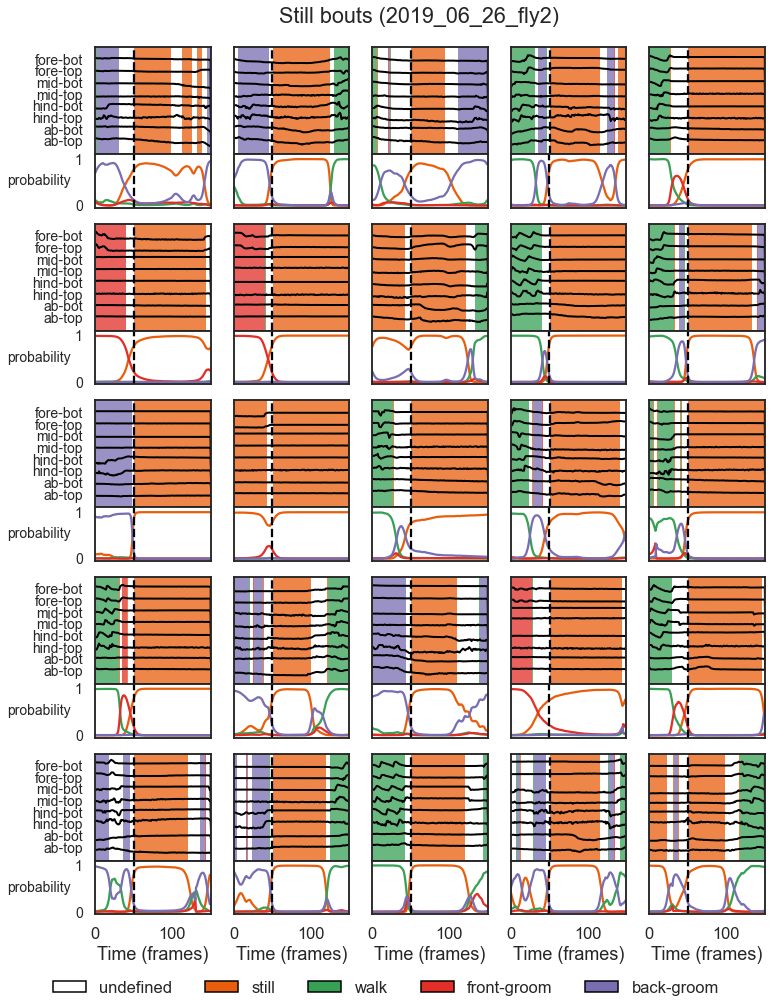

/home/mattw/anaconda3/envs/daart/lib/python3.6/site-packages/ipykernel_launcher.py:169: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 


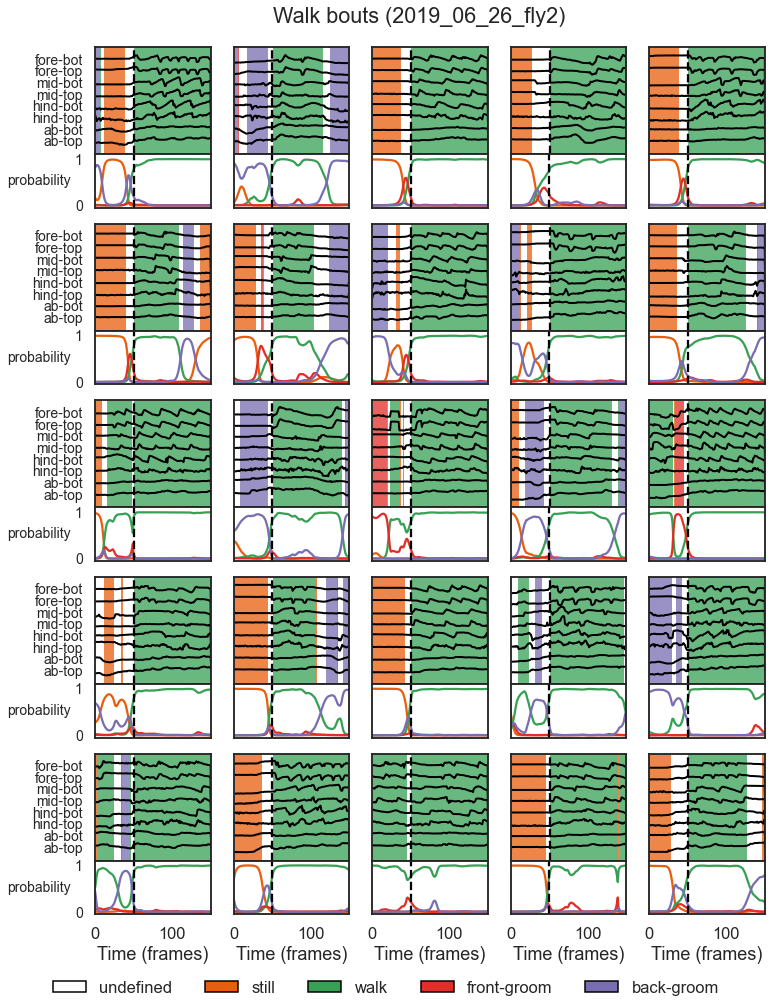

/home/mattw/anaconda3/envs/daart/lib/python3.6/site-packages/ipykernel_launcher.py:169: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 


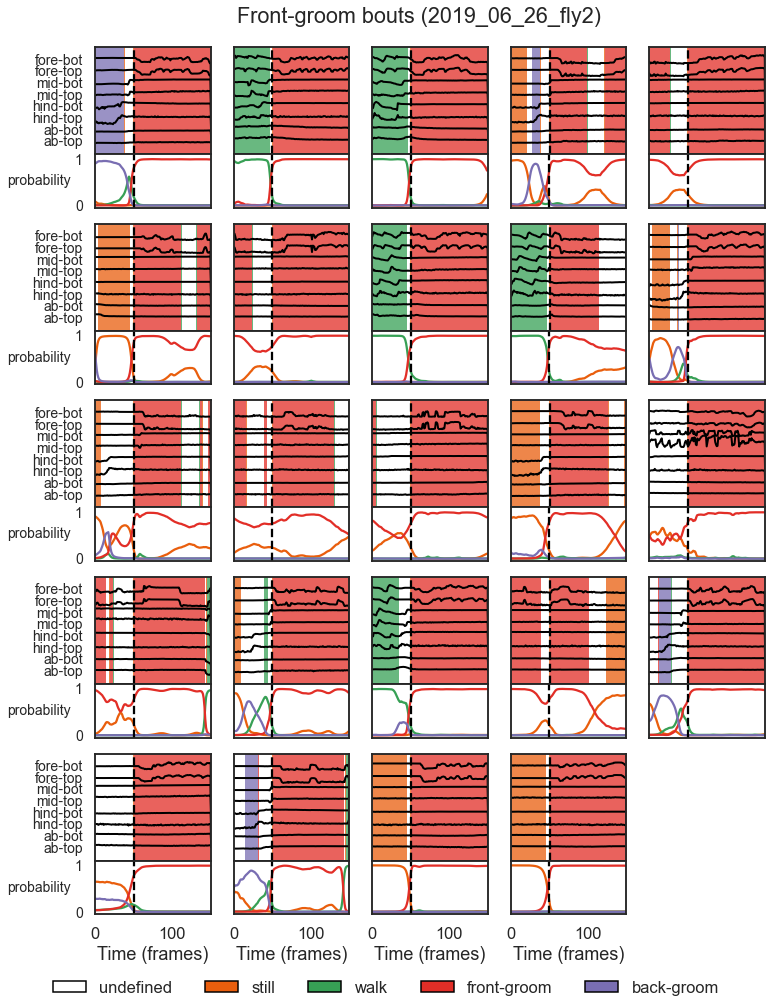

/home/mattw/anaconda3/envs/daart/lib/python3.6/site-packages/ipykernel_launcher.py:169: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 


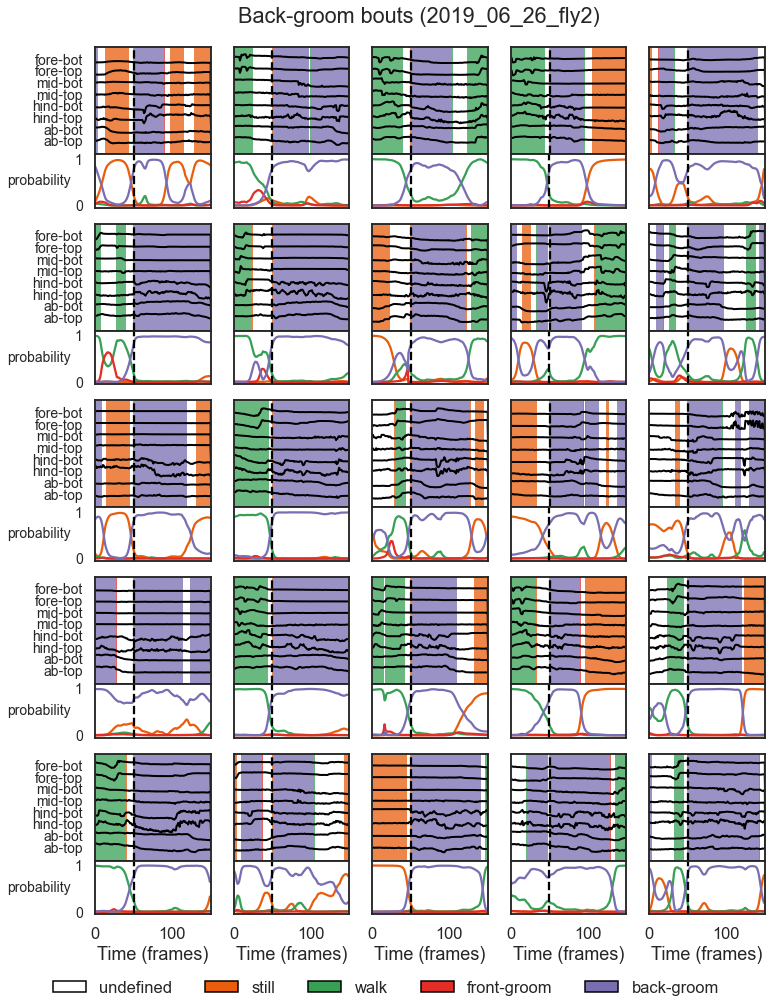

In [15]:
# expt_ids_test = EXPT_IDS_ALL[0]
expt_ids_test = [
    '2019_06_26_fly2',
#     '2019_06_30_fly1',
#     '2019_07_01_fly2',
#     '2019_08_07_fly2',
#     '2019_08_08_fly1',
#     '2019_08_08_fly1_1',
#     '2019_08_13_fly3',
#     '2019_08_14_fly1',
#     '2019_08_20_fly2',
#     '2019_08_20_fly3',
#     '2019_10_10_fly3',
#     '2019_10_14_fly2',
#     '2019_10_14_fly3',
#     '2019_10_18_fly3',
#     '2019_10_21_fly1',
]

for expt_id_test in expt_ids_test:

    # -------------------------------------------------------
    # Load data
    # -------------------------------------------------------
    # DLC markers
    markers_file = os.path.join(base_dir, 'markers', expt_id_test + '_labeled.h5')
    # hand labels
#     hand_labels_file = os.path.join(
#         base_dir, 'labels_deepethogram', 'DATA', expt_id_test, expt_id_test + '_labels.csv')
#     # heuristic labels
#     labels_file = os.path.join(base_dir, 'labels-heuristic', expt_id_test + '_labels.pkl')
    hand_labels_file = os.path.join(
        base_dir, 'labels-hand', 'no-abdomen', expt_id_test + '_labels.csv')
    # heuristic labels
    labels_file = os.path.join(
        base_dir, 'labels-heuristic', 'states-v3', expt_id_test + '_labels.pkl')

    # define data generator signals
    signals = ['markers']
    transforms = [ZScore()]
    paths = [markers_file]

    # build data generator
    data_gen_test = DataGenerator(
        [expt_id_test], [signals], [transforms], [paths], device=device, batch_size=batch_size, 
        trial_splits=trial_splits)
    print(data_gen_test)

    # load hand labels
    labels = genfromtxt(hand_labels_file, delimiter=',', dtype=np.int, encoding=None)
    labels = labels[1:, 1:]  # get rid of headers, etc.
    states = np.argmax(labels, axis=1)
    cutoff = int(np.floor(states.shape[0] / batch_size)) * batch_size
    labels_hand = states[:cutoff]

    # load heuristic labels
    with open(labels_file, 'rb') as f:
        labels_heur = pickle.load(f)['states']
        labels_heur = labels_heur[:cutoff]

    # load markers
    with h5py.File(markers_file, 'r') as f:
        t = f['df_with_missing']['table'][()]
    dlc = np.concatenate([t[i][1][None, :] for i in range(len(t))])
    x = dlc[:, 0::3]
    y = dlc[:, 1::3]
    markers = x # np.hstack([x, y])
    
    # compute predictions
    print('computing predictions...', end='')
    tmp = model.predict_labels(data_gen_test, return_scores=True)
    labels_pred = np.vstack(tmp['labels'][0])
    labels_model = np.argmax(labels_pred, axis=1)
    z = np.vstack(tmp['embedding'][0])
    # scores = np.vstack(tmp['scores'][0])
    print('done')

    probs_max = np.max(labels_pred, axis=1)
    labels_model_thresh = np.copy(labels_model)
    labels_model_thresh[probs_max < 0.75] = 0

    # -------------------------------------------------------
    # Extract behavior bouts
    # -------------------------------------------------------
    min_length = 40
    n_bouts = 25

    np.random.seed(get_expt_rng(expt_id_test))
    bout_start_idxs = {}

    snippets = extract_state_runs(labels_model_thresh, min_length=min_length)

    for i, state_id in enumerate(label_names[1:]):
        if len(snippets[i+1]) > n_bouts:
            idxs = np.random.choice(len(snippets[i+1]), n_bouts, replace=False)
        else:
            idxs = np.arange(len(snippets[i+1]))
        bout_start_idxs[state_id] = [snippets[i+1][ii][0] for ii in idxs]
        
    # -------------------------------------------------------
    # Plot state snippets
    # -------------------------------------------------------
    plot_state_snippets()

In [29]:
scores_0 = get_precision_recall(
    labels_hand, labels_model, background=0, n_classes=n_classes-1)['f1']
scores_0

array([0.94043887, 1.        , 1.        , 0.91840607, 0.99637944])

In [30]:
labels_pred_tmp = np.copy(labels_pred)
max_probs = np.max(labels_pred_tmp, axis=1)
labels_pred_tmp[max_probs < 0.75] = 0
labels_model_tmp = np.argmax(labels_pred_tmp, axis=1)
scores = get_precision_recall(
    labels_hand, labels_model_tmp, background=0, n_classes=n_classes-1)['f1']
scores

array([0.95666132, 0.99159664, 1.        , 0.85947047, 0.98387097])

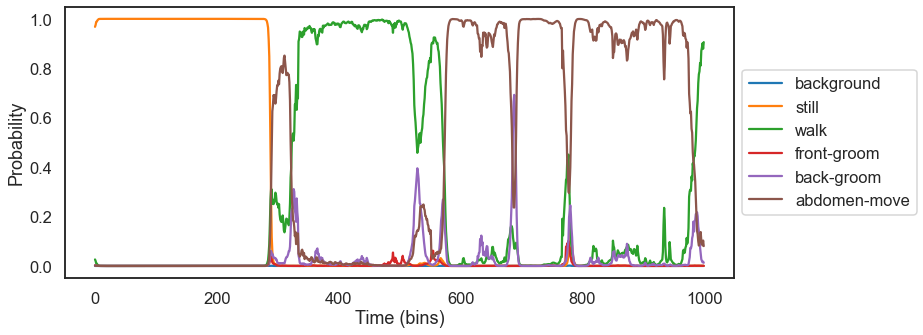

In [31]:
i = (0, 1000)

sns.set_style('white')
sns.set_context('talk')
plt.figure(figsize=(12, 5))
for l_idx, l in enumerate(label_names):
    plt.plot(labels_pred[slice(*i), l_idx], label=l)
plt.xlabel('Time (bins)')
plt.ylabel('Probability')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [32]:
np.max(labels_pred, axis=0)

array([0.00442598, 0.9999933 , 0.9988146 , 0.999951  , 0.99422497,
       0.99989057], dtype=float32)

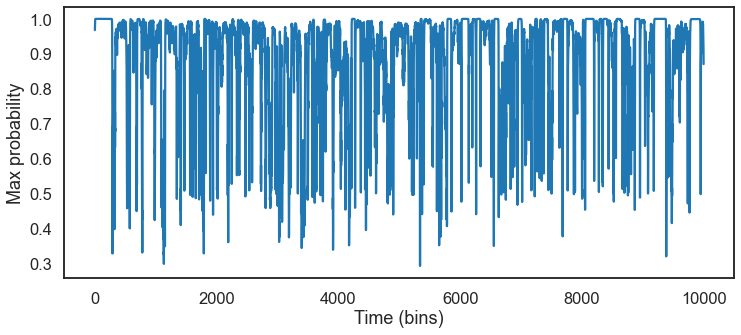

In [33]:
probs_max = np.max(labels_pred, axis=1)

sns.set_style('white')
sns.set_context('talk')
plt.figure(figsize=(12, 5))
plt.plot(probs_max[:10000])
plt.xlabel('Time (bins)')
plt.ylabel('Max probability')
plt.show()

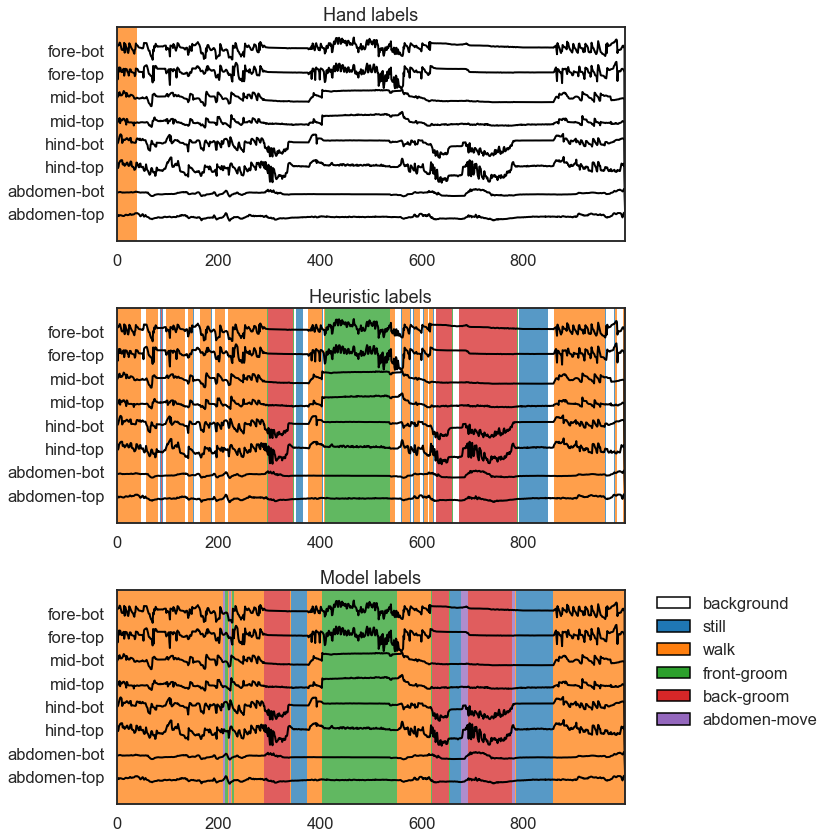

In [88]:
sns.set_context('talk')
sns.set_style('white')

i = (5000, 6000)
# i = (2000, 3000)  # walk/abdomen-move
# i = (1000, 2000)  # walk/abdomen-move
# i = (15100, 15400)  # front groom
# i = (37900, 38200)  # front groom
# i = (56200, 56500)  # front groom

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

n_frames = i[1] - i[0]
times = np.arange(n_frames + n_classes)

markers_z = (markers - np.mean(markers, axis=0)) / np.std(markers, axis=0)
spc = 1.0 * abs(markers_z.max())
plotting_markers = markers_z + spc * np.arange(n_markers)
ymin = min(-spc - 1, np.min(plotting_markers))
ymax = max(spc * n_markers, np.max(plotting_markers))

# plot hand states
plot_markers_and_states(
    times, plotting_markers, labels_hand, 'Hand labels', axes[0])

# plot heuristic states
plot_markers_and_states(
    times, plotting_markers, labels_heur, 'Heuristic labels', axes[1])

# plot model-based states
im = plot_markers_and_states(
    times, plotting_markers, labels_model, 'Model labels', axes[2])

# get the colors of the values, according to the 
# colormap used by imshow
colors = [im.cmap(im.norm(value)) for value in range(n_classes)]
# create a patch (proxy artist) for every color 
patches = [
    mpatches.Patch(facecolor=colors[i], label=label_names[i], edgecolor='k') 
    for i in range(n_classes)]
# put those patched as legend-handles into the legend
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0, frameon=False)

plt.tight_layout()
plt.show()

In [79]:
state_lens_model = run_lengths(labels_model)
state_lens_heur = run_lengths(labels_heur)

/home/mattw/anaconda3/envs/daart/lib/python3.6/site-packages/ipykernel_launcher.py:10: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification is deprecated since 3.3 and will be removed two minor releases later.
  # Remove the CWD from sys.path while we load stuff.


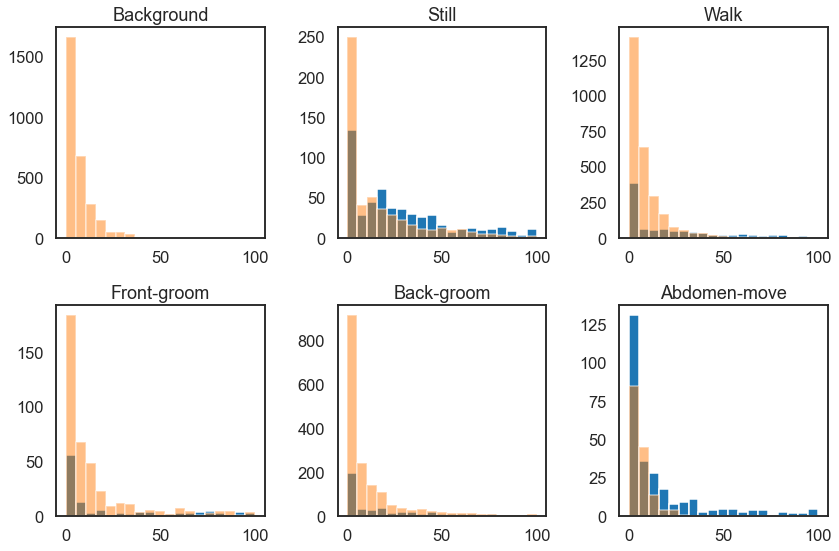

In [80]:
# plot distribution of state durations
n_cols = 3
n_rows = np.ceil(5 / n_cols)

bins = np.linspace(0, 100, 20)

fig = plt.figure(figsize=(4 * n_cols, 4 * n_rows))

for i, label_name in enumerate(label_names):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.hist(state_lens_model[i], bins=bins)
    plt.hist(state_lens_heur[i], bins=bins, alpha=0.5)
    plt.title(label_name.capitalize())
plt.tight_layout()
plt.show()

In [89]:
idxs_select = probs_max > 0.75

In [90]:
np.sum(idxs_select) / idxs_select.shape[0]

0.7588306451612903

In [91]:
state_lens_ml = run_lengths(labels_model[idxs_select])
state_lens_ms = run_lengths(labels_model[~idxs_select])

/home/mattw/anaconda3/envs/daart/lib/python3.6/site-packages/ipykernel_launcher.py:10: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification is deprecated since 3.3 and will be removed two minor releases later.
  # Remove the CWD from sys.path while we load stuff.


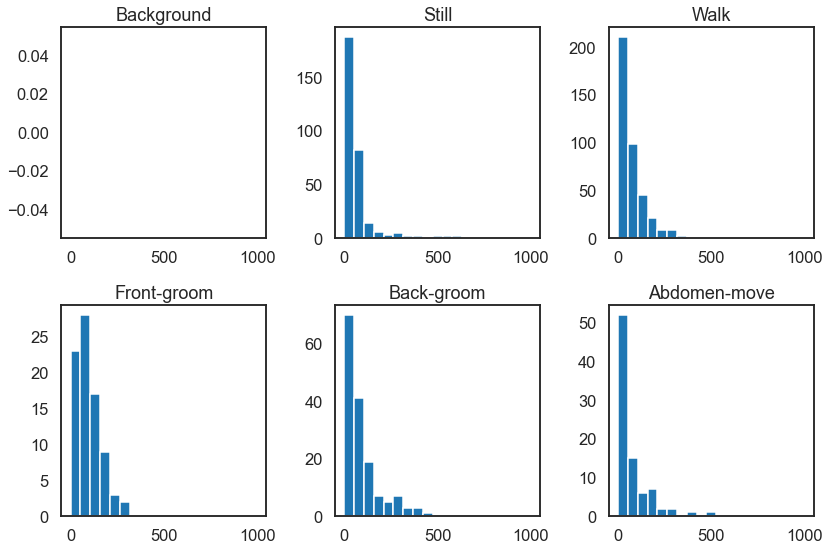

In [95]:
# plot distribution of state durations
n_cols = 3
n_rows = np.ceil(5 / n_cols)

bins = np.linspace(0, 1000, 20)

fig = plt.figure(figsize=(4 * n_cols, 4 * n_rows))

for i, label_name in enumerate(label_names):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.hist(state_lens_ml[i], bins=bins)
#     plt.hist(state_lens_ms[i], bins=bins, alpha=0.5)
    plt.title(label_name.capitalize())
plt.tight_layout()
plt.show()